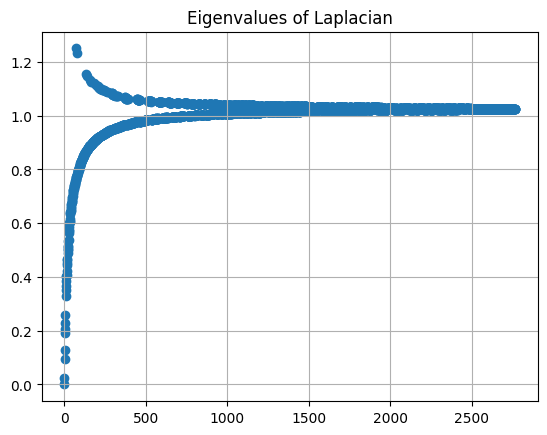

Optimal # of regimes (clusters): 75


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csgraph
from numpy import linalg as LA
from sklearn.cluster import SpectralClustering

# --- Load your real feature data (z-score normalized, drop dates) ---
df = pd.read_csv("X_combined_scaled_new.csv")
X = df.drop(columns=["Date"])  # only numeric features

# --- Step 1: Compute Affinity Matrix ---
def getAffinityMatrix(coordinates, k=5):
    dists = squareform(pdist(coordinates))
    knn_distances = np.sort(dists, axis=0)[k]
    knn_distances = knn_distances[np.newaxis].T
    local_scale = knn_distances.dot(knn_distances.T)
    affinity_matrix = dists * dists
    affinity_matrix = -affinity_matrix / local_scale
    affinity_matrix[np.isnan(affinity_matrix)] = 0.0
    affinity_matrix = np.exp(affinity_matrix)
    np.fill_diagonal(affinity_matrix, 0)
    return affinity_matrix

A = getAffinityMatrix(X.values, k=10)

# --- Step 2: Eigengap heuristic to determine optimal K ---
def eigenDecomposition(A, plot=True, topK=5):
    L = csgraph.laplacian(A, normed=True)
    eigenvalues, eigenvectors = LA.eig(L)
    if plot:
        plt.title("Eigenvalues of Laplacian")
        plt.scatter(np.arange(len(eigenvalues)), eigenvalues)
        plt.grid()
        plt.show()
    gap_indices = np.argsort(np.diff(eigenvalues))[::-1][:topK]
    nb_clusters = gap_indices[0] + 1  # index of largest gap + 1
    return nb_clusters, eigenvalues, eigenvectors

optimal_k, _, _ = eigenDecomposition(A, plot=True)
print("Optimal # of regimes (clusters):", optimal_k)


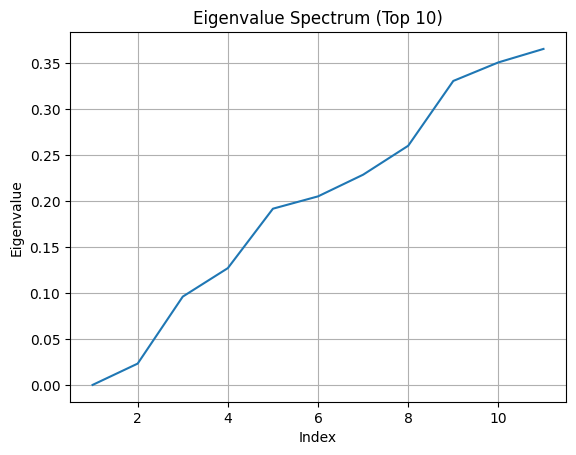

Optimal number of regimes (clusters): 2
✅ Saved to X_with_spectral_regimes.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csgraph
from numpy import linalg as LA
from sklearn.cluster import SpectralClustering

# Step 1: Load data (drop 'Date' to keep only numeric features)

df = pd.read_csv("X_combined_scaled_new.csv")
X = df.drop(columns=["Date"])

# Step 2: Define affinity matrix using local scaling (k-nearest neighbors)
def getAffinityMatrix(coordinates, k=10):
    dists = squareform(pdist(coordinates))
    knn_distances = np.sort(dists, axis=0)[k]
    knn_distances = knn_distances[np.newaxis].T
    local_scale = knn_distances.dot(knn_distances.T)
    affinity_matrix = - (dists ** 2) / local_scale
    affinity_matrix[np.isnan(affinity_matrix)] = 0.0
    affinity_matrix = np.exp(affinity_matrix)
    np.fill_diagonal(affinity_matrix, 0)
    return affinity_matrix

A = getAffinityMatrix(X.values, k=10)

# Step 3: Eigengap heuristic to determine optimal number of clusters
def eigenDecomposition(A, topK=10):
    L = csgraph.laplacian(A, normed=True)
    eigenvalues, _ = LA.eigh(L)
    diffs = np.diff(eigenvalues[:topK+1])
    
    # Plot eigenvalues
    plt.plot(np.arange(1, topK+2), eigenvalues[:topK+1])
    plt.title("Eigenvalue Spectrum (Top 10)")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.grid(True)
    plt.show()

    best_k = np.argmax(diffs) + 1
    return best_k

optimal_k = eigenDecomposition(A, topK=10)
print("Optimal number of regimes (clusters):", optimal_k)

# Step 4: Apply spectral clustering with optimal_k
spectral = SpectralClustering(n_clusters=optimal_k, affinity='precomputed', assign_labels='kmeans', random_state=0)
regime_labels = spectral.fit_predict(A)

# Step 5: Append regime labels and save to CSV
df["Regime"] = regime_labels
df.to_csv("X_with_spectral_regimes.csv", index=False)
print("✅ Saved to X_with_spectral_regimes.csv")


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load full data with Date column
y = pd.read_csv("/work/y_scaled.csv", index_col=0)
X = pd.read_csv("/work/X.csv", index_col=0)

# Step 1: Truncate to in-sample
X_test = X[1176:]
y_test = y[1176:]
X = X[0:1176]
y = y[0:1176]

X.to_csv("X_train_val.csv", index=True)

# Step 2: Preserve Date column and split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Save X_train with Date column to CSV
X_train.to_csv("X_train_with_dates.csv", index=True)


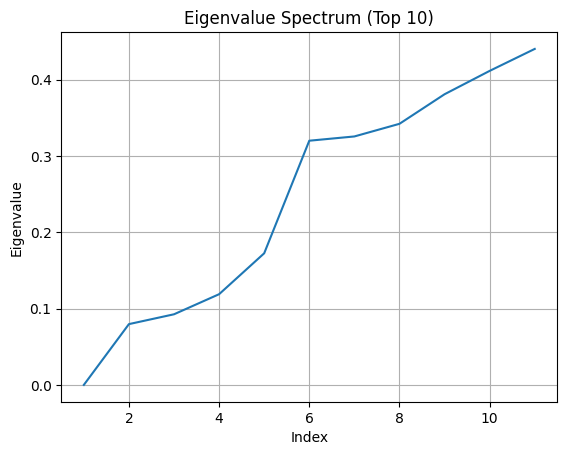

Optimal number of regimes (clusters): 5
✅ Saved to X_with_spectral_regimes.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csgraph
from numpy import linalg as LA
from sklearn.cluster import SpectralClustering

# Step 1: Load data (drop 'Date' to keep only numeric features)

df = pd.read_csv("X_train_val.csv")
X = df.drop(columns=["Date"])

# Step 2: Define affinity matrix using local scaling (k-nearest neighbors)
def getAffinityMatrix(coordinates, k=10):
    dists = squareform(pdist(coordinates))
    knn_distances = np.sort(dists, axis=0)[k]
    knn_distances = knn_distances[np.newaxis].T
    local_scale = knn_distances.dot(knn_distances.T)
    affinity_matrix = - (dists ** 2) / local_scale
    affinity_matrix[np.isnan(affinity_matrix)] = 0.0
    affinity_matrix = np.exp(affinity_matrix)
    np.fill_diagonal(affinity_matrix, 0)
    return affinity_matrix

A = getAffinityMatrix(X.values, k=10)

# Step 3: Eigengap heuristic to determine optimal number of clusters
def eigenDecomposition(A, topK=10):
    L = csgraph.laplacian(A, normed=True)
    eigenvalues, _ = LA.eigh(L)
    diffs = np.diff(eigenvalues[:topK+1])
    
    # Plot eigenvalues
    plt.plot(np.arange(1, topK+2), eigenvalues[:topK+1])
    plt.title("Eigenvalue Spectrum (Top 10)")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.grid(True)
    plt.show()

    best_k = np.argmax(diffs) + 1
    return best_k

optimal_k = eigenDecomposition(A, topK=10)
print("Optimal number of regimes (clusters):", optimal_k)

# Step 4: Apply spectral clustering with optimal_k
spectral = SpectralClustering(n_clusters=optimal_k, affinity='precomputed', assign_labels='kmeans', random_state=0)
regime_labels = spectral.fit_predict(A)

# Step 5: Append regime labels and save to CSV
df["Regime"] = regime_labels
df.to_csv("X_with_spectral_regimes.csv", index=False)
print("✅ Saved to X_with_spectral_regimes.csv")

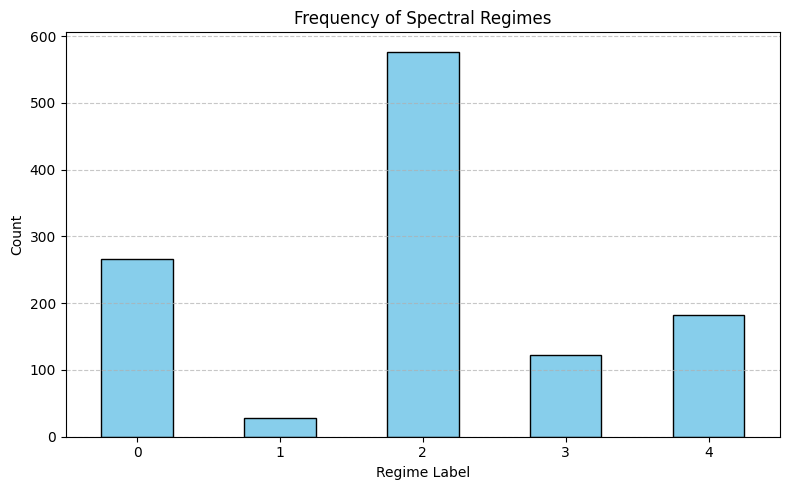

In [5]:
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("X_with_spectral_regimes.csv")

plt.figure(figsize=(8, 5))
df['Regime'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frequency of Spectral Regimes")
plt.xlabel("Regime Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
df = pd.read_csv("X_with_spectral_regimes.csv")

X = df.drop(columns=["Date", "Regime"])
y = df["Regime"]

from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    multi_class = "multinomial",
    solver='lbfgs',
    max_iter=1000,
    random_state=42)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
Confusion Matrix:
 [[ 49   0   0   0   0]
 [  0   3   0   0   0]
 [  1   0 118   1   1]
 [  0   0   0  25   0]
 [  0   0   2   0  36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        49
           1       1.00      1.00      1.00         3
           2       0.98      0.98      0.98       121
           3       0.96      1.00      0.98        25
           4       0.97      0.95      0.96        38

    accuracy                           0.98       236
   macro avg       0.98      0.98      0.98       236
weighted avg       0.98      0.98      0.98       236



In [7]:
import pandas as pd

df = pd.read_csv("cluster_labels.csv")
df2 = pd.read_csv("X_train_val.csv")

X = df2.drop(columns=["Date"])
y = df

from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    multi_class = "multinomial",
    solver='lbfgs',
    max_iter=1000,
    random_state=42)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


/root/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
Confusion Matrix:
 [[ 0  0  0  4]
 [ 0 61  0  0]
 [ 0  0 68  2]
 [ 0  0  4 97]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       1.00      1.00      1.00        61
           2       0.94      0.97      0.96        70
           3       0.94      0.96      0.95       101

    accuracy                           0.96       236
   macro avg       0.

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification

import pandas as pd

df = pd.read_csv("cluster_labels.csv")
df2 = pd.read_csv("X_train_val.csv")

X = df2.drop(columns=["Date"])
y = df

from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    multi_class = "multinomial",
    solver='lbfgs',
    max_iter=1000,
    random_state=42)

logreg.fit(X_resampled, y_resampled)

y_pred = logreg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/root/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
Confusion Matrix:
 [[ 3  1  0  0]
 [ 0 61  0  0]
 [ 5  0 64  1]
 [20  0 10 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.11      0.75      0.19         4
           1       0.98      1.00      0.99        61
           2       0.86      0.91      0.89        70
           3       0.99      0.70      0.82       101

    accuracy                           0.84       236
   macro avg       0.

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification

import pandas as pd

df = pd.read_csv("X_with_spectral_regimes.csv")

X = df.drop(columns=["Date", "Regime"])
y = df["Regime"]

from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    multi_class = "multinomial",
    solver='lbfgs',
    max_iter=1000,
    random_state=42)

logreg.fit(X_resampled, y_resampled)

y_pred = logreg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
Confusion Matrix:
 [[ 49   0   0   0   0]
 [  0   3   0   0   0]
 [  1   0 117   2   1]
 [  0   0   0  25   0]
 [  0   0   1   0  37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        49
           1       1.00      1.00      1.00         3
           2       0.99      0.97      0.98       121
           3       0.93      1.00      0.96        25
           4       0.97      0.97      0.97        38

    accuracy                           0.98       236
   macro avg       0.97      0.99      0.98       236
weighted avg       0.98      0.98      0.98       236



In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification

import pandas as pd

df = pd.read_csv("cluster_labels_1.csv")
df2 = pd.read_csv("X_train_val.csv")

X = df2.drop(columns=["Date"])
y = df

from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    multi_class = "multinomial",
    solver='lbfgs',
    max_iter=1000,
    random_state=42)

logreg.fit(X_resampled, y_resampled)

y_pred = logreg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/root/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
Confusion Matrix:
 [[60  0  5  5  0]
 [ 4 59  4 22  0]
 [ 2  0 10  0  0]
 [ 0  0  0  3  1]
 [ 0  0  0  0 61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.86      0.88        70
           1       1.00      0.66      0.80        89
           2       0.53      0.83      0.65        12
           3       0.10      0.75      0.18         4
           4       0.98      1.00      0.99   

/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

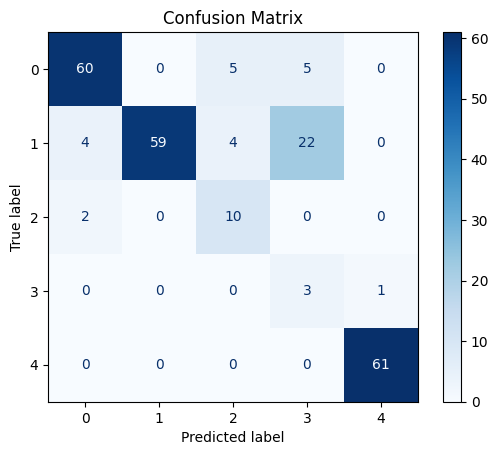

In [14]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Load data
df = pd.read_csv("cluster_labels_1.csv")
df2 = pd.read_csv("X_train_val.csv")

# Drop date and define X, y
X = df2.drop(columns=["Date"])
y = df.values.ravel()  # flatten y to 1D array for scikit-learn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE for balancing classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2'],  # 'l1' works only with saga, so limit here
    'max_iter': [1000],
    'multi_class': ['multinomial']
}

# GridSearchCV to tune parameters
grid = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_resampled, y_resampled)

# Use best model to predict on test data
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Output results
print("Best Parameters:", grid.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [10]:
probs = best_model.predict_proba(X_test)
print(probs)

[[9.99070383e-01 1.17291365e-04 7.63458660e-04 3.89293455e-05
  9.93749616e-06]
 [1.46228827e-04 2.86729178e-03 8.32107128e-06 1.94466978e-04
  9.96783691e-01]
 [9.35434966e-01 3.15528859e-03 6.11726242e-02 2.03464348e-04
  3.36568678e-05]
 ...
 [2.64182040e-03 4.95156025e-03 8.05963495e-06 2.59534901e-03
  9.89803211e-01]
 [2.59247392e-02 5.78187986e-01 1.72207813e-01 2.23508250e-01
  1.71212453e-04]
 [7.60401537e-04 7.90900182e-01 1.73357397e-01 1.61304420e-02
  1.88515772e-02]]


In [86]:
from sklearn.linear_model import LogisticRegression
import joblib


In [91]:
joblib.dump(best_model, "logistic_model_SMOTE.joblib")


['logistic_model_SMOTE.joblib']

In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split

y = pd.read_csv("/work/y_combined_scaled_new.csv", index_col=0)
X = pd.read_csv("/work/X_combined_scaled_new.csv", index_col=0)

X_test = X[2213:]
y_test = y[2213:]
X = X[0:2213]
y = y[0:2213]



In [46]:
! pip uninstall -y scikit-learn


Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2


In [49]:
! pip install scikit-learn


  Using cached scikit_learn-1.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [61]:
import sklearn.base
!pip install --force-reinstall -U scikit-learn

  Using cached scikit_learn-1.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 66.3 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Can't uninstall 'numpy'. No files were found to uninstall.
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. T

In [4]:
import pandas as pd
import sklearn.base
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

y = pd.read_csv("cluster_labels_revised.csv")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    multi_class = "multinomial",
    solver='lbfgs',
    max_iter=1000,
    random_state=24)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/root/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Confusion Matrix:
 [[171   5   0]
 [ 10 154   4]
 [  0   8  91]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       176
           1       0.92      0.92      0.92       168
           2       0.96      0.92      0.94        99

    accuracy                           0.94       443
   macro avg       0.94      0.94      0.94       443
weighted avg       0.94      0.94      0.94       443



In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split

y = pd.read_csv("/work/y_combined_scaled_new.csv", index_col=0)
X = pd.read_csv("/work/X_combined_scaled_new.csv", index_col=0)

X_test = X[1106:1383]
y_test = y[1106:1383]
X = X[0:1106]
y = y[0:1106]



In [4]:
import pandas as pd
import sklearn.base
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

y = pd.read_csv("cluster_labels_revised_new.csv")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=24)


from sklearn.metrics import classification_report, confusion_matrix

logreg = LogisticRegression(
    multi_class = "multinomial",
    solver='lbfgs',
    max_iter=1000,
    random_state=24)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_val)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

/root/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Confusion Matrix:
 [[90  0  1  2]
 [ 1 29  0  0]
 [ 0  0 44  9]
 [ 2  0 16 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        93
           1       1.00      0.97      0.98        30
           2       0.72      0.83      0.77        53
           3       0.72      0.61      0.66        46

    accuracy                           0.86       222
   macro avg       0.85      0.84      0.85       222
weighted avg       0.86      0.86      0.86       222

